# [LAB 99] AutoML > 01-PyCaret

## #01.PyCaret 개요
- 파이썬 기반 AutoML 라이브러리
  - 전처리 -> 모델 비교 -> 튜닝 ->평가 -> 해석을 한 줄 코드로 자동화
  - 머신러닝 실무 파이프라인 전체를 빠르게 실험하는 도구
- 개별 알고리즘 구현 능력 -> 모델 선택/비교/의사결정 능력으로 확장
   - 실험비용 감소
   - 캡스폰, 포트폴리오, 프로토타입에 유용


### 기존 학습과의 연결

| 기존에 배운 것        | PyCaret에서의 역할        |
| --------------- | -------------------- |
| train / test 분리 | `setup()` 내부에서 자동 수행 |
| 스케일링, 인코딩       | 자동 전처리               |
| 여러 분류모델 학습      | `compare_models()`   |
| GridSearchCV    | `tune_model()`       |
| 성능 비교           | 자동 랭킹 테이블            |
| SHAP, 중요도       | `interpret_model()`  |



#### PyCaret 작업 흐름
데이터 준비
  ↓
setup()
  ↓
compare_models()
  ↓
select / tune_model()
  ↓
evaluate_model()
  ↓
interpret_model()


- ✅ PyCaret의 장점
코드량 극단적으로 감소
모델 간 성능 비교가 직관적
실험 재현성 높음
SHAP 기반 해석 바로 가능

- ⚠️ PyCaret의 한계
내부 동작이 블랙박스처럼 보일 수 있음
전처리 세부 제어에는 제한이 있음
AutoML 결과를 비판적으로 해석하지 않으면 위험
👉 기초 머신러닝을 배운 뒤에 써야 의미 있음

- 📌 수업에서의 위치 정리
❌ 머신러닝 입문용 아님
✅ 분류/회귀 학습 후 정리·확장 단계
✅ “실무에서는 이렇게 실험한다”를 보여주는 도구

## #02. 준비 작업
### [1] 패키지 참조 및 함수 정의

In [32]:
from hossam import *
from pandas import concat
from pycaret.regression import *


from hossam import *



import pandas as pd
from pandas import Series, DataFrame

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from itertools import product

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 성능평가지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

from pandas import merge


#BoostRegressor
from xgboost import XGBRegressor

#### 성능 평가 함수

In [33]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#### 변수 중요도 확인

In [34]:
from sklearn.inspection import permutation_importance

def hs_feature_importance(model, x, y):
    perm = permutation_importance(
        estimator=model,
        X=x,
        y=y,
        scoring="r2",
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
    )

    # 결과 정리
    perm_df = DataFrame(
        {
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        },
        index=x.columns,
    ).sort_values("importance_mean", ascending=False)

    # 시각화
    df = perm_df.sort_values(by="importance_mean", ascending=False)

    figsize = (1280 / my_dpi, 600 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.barplot(data=df, x="importance_mean", y=df.index)

    ax.set_title("Permutation Importance")
    ax.set_xlabel("Permutation Importance (mean)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return perm_df


#### 과적합 판정 함수

In [35]:
import matplotlib.pyplot as plt

my_dpi = 100  # 없으면 기본값

def create_figure(figsize=(1280/100, 720/100), dpi=None):
    if dpi is None:
        dpi = my_dpi
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    return fig, ax

def finalize_plot(ax):
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


In [36]:
def hs_learning_cv(
    estimator, x, y, scoring="neg_root_mean_squared_error",
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
):

    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 정량 판정
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과소적합 기준선 (some_threshold)
    # -------------------------

    # 기준모형 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    # → 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도의 성능은 내야 한다는 기준을 설정하는 것
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "⚠️ 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "⚠️ 과대적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "⚠️ 데이터 부족 / 분산 큼"
    else:
        status = "⚠️ 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "Train RMSE": [final_train],
            "CV RMSE 평균": [final_cv],
            "CV RMSE 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------

    fig, ax = create_figure()

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    ax.set_xlabel("RMSE", fontsize=8, labelpad=5)  # type: ignore
    ax.set_ylabel("학습곡선 (Learning Curve)", fontsize=8, labelpad=5)  # type: ignore
    ax.grid(True, alpha=0.3)  # type: ignore

    finalize_plot(ax)

    return result_df


#### 성능평가 + 과적합 판정 동시 수행 함수

In [37]:
def hs_get_score_cv(
    estimator,
    x_test,
    y_test,
    x_origin,
    y_origin,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    score_df = hs_get_scores(estimator, x_test, y_test)

    cv_df = hs_learning_cv(
        estimator,
        x_origin,
        y_origin,
        scoring=scoring,
        cv=cv,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
    )

    return merge(score_df, cv_df, left_index=True, right_index=True)


#### SHAP 분석

In [38]:
def hs_shap_analysis(
    model,
    x: DataFrame,
    plot: bool = True,
    width: int = 1600,
    height: int = 800,
):
    # -------------------------------------------------
    # 1. SHAP Explainer 생성 (트리 모델용)
    # -------------------------------------------------
    explainer = shap.TreeExplainer(model)

    # -------------------------------------------------
    # 2. SHAP 값 계산
    # shape = (n_samples, n_features)
    # -------------------------------------------------
    shap_values = explainer.shap_values(x)

    # -------------------------------------------------
    # 3. SHAP DataFrame 변환
    # -------------------------------------------------
    shap_df = DataFrame(
        shap_values,
        columns=x.columns,
        index=x.index,
    )

    # -------------------------------------------------
    # 4. SHAP 요약 통계
    # -------------------------------------------------
    summary_df = DataFrame(
        {
            "feature": shap_df.columns,
            "mean_abs_shap": shap_df.abs().mean().values,
            "mean_shap": shap_df.mean().values,
            "std_shap": shap_df.std().values,
        }
    )

    # -------------------------------------------------
    # 5. 영향 방향 (보수적 기준)
    # -------------------------------------------------
    summary_df["direction"] = np.where(
        summary_df["mean_shap"] > 0,
        "양(+) 경향",
        np.where(summary_df["mean_shap"] < 0, "음(-) 경향", "혼합/미약"),
    )

    # -------------------------------------------------
    # 6. 변동성 지표 (안정성 판단)
    # -------------------------------------------------
    summary_df["cv"] = (
        summary_df["std_shap"] / (summary_df["mean_abs_shap"] + 1e-9)
    )

    summary_df["variability"] = np.where(
        summary_df["cv"] < 1,
        "stable",      # 평균 대비 변동성 낮음
        "variable",    # 상황 의존적 영향
    )

    # -------------------------------------------------
    # 7. 중요도 기준 정렬
    # -------------------------------------------------
    summary_df = (
        summary_df
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    # -------------------------------------------------
    # 8. 중요 변수 판별 (누적 80%)
    # -------------------------------------------------
    total_importance = summary_df["mean_abs_shap"].sum()

    summary_df["importance_ratio"] = (
        summary_df["mean_abs_shap"] / total_importance
    )

    summary_df["importance_cumsum"] = (
        summary_df["importance_ratio"].cumsum()
    )

    summary_df["is_important"] = np.where(
        summary_df["importance_cumsum"] <= 0.80,
        "core",        # 핵심 변수
        "secondary",   # 보조 변수
    )

    # -------------------------------------------------
    # 9. SHAP Summary Plot
    # -------------------------------------------------
    if plot:
        shap.summary_plot(shap_values, x, show=False)

        fig = plt.gcf()
        fig.set_size_inches(width / 100, height / 100)

        plt.title("SHAP Summary Plot", fontsize=10, pad=10)
        plt.xlabel("SHAP value", fontsize=8)
        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    # -------------------------------------------------
    return summary_df, shap_values


#### SHAP dependance

In [39]:
def hs_shap_dependence_analysis(
    summary_df: DataFrame,
    shap_values,
    x_train: DataFrame,
    include_secondary: bool = False, #core 변수가 너무 적을 때, True 로 설정하면 secondary 까지 포함
    width: int = 1600,
    height: int = 800,
):
    # 1. 주 대상 변수 (Core + Variable)
    main_features = summary_df[
        (summary_df["is_important"] == "core")
        & (summary_df["variability"] == "variable")
    ]["feature"].tolist()

    # 2. 상호작용 후보 변수
    interaction_features = summary_df[
        summary_df["is_important"] == "core"
    ]["feature"].tolist()

    if include_secondary and len(interaction_features) < 2:
        interaction_features.extend(
            summary_df[summary_df["is_important"] == "secondary"]["feature"].tolist()
        )

    # 3. 변수 쌍 생성 (자기 자신 제외)
    pairs = []
    for f in main_features:
        for inter in interaction_features:
            # 자기 자신과의 조합은 제외
            if f != inter:
                pairs.append((f, inter))

    # 중요도 순 정렬 (주 변수 기준)
    importance_rank = {}
    for i, row in summary_df.iterrows():
        importance_rank[row["feature"]] = i

    pairs = sorted(
        pairs,
        key=lambda x: importance_rank.get(x[0], 999),
    )

    # 4. dependence plot 일괄 생성
    for feature_name, interaction_name in pairs:
        shap.dependence_plot(
            feature_name,
            shap_values,
            x_train,
            interaction_index=interaction_name,
            show=False,
        )

        # SHAP figure 직접 제어
        fig = plt.gcf()
        fig.set_size_inches(width / my_dpi, height / my_dpi)

        plt.title(
            f"SHAP Dependence Plot: {feature_name} × {interaction_name}",
            fontsize=10,
            pad=10,
        )

        plt.xlabel(feature_name, fontsize=10)
        plt.ylabel(f"SHAP value for {feature_name}", fontsize=10)

        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    return pairs


### [2] 데이터 불러오기 + 인덱스 설정 + 카테고리 타입 지정

In [40]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)


# XGBoost 라서 astype int 처리
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


## #02. Pycaret setup
### [1] setup()



In [41]:
from pycaret.regression import RegressionExperiment

# 실험 객체 생성
s = RegressionExperiment()

# setup
s.setup(
    # -------------------------------
    # 기본 설정 (필수 지정)
    # -------------------------------
    data=origin,                 # 데이터셋
    target="sales",              # 예측 목표 변수
    session_id=52,               # 랜덤 시드 고정
    train_size=0.75,             # 훈련 데이터 비율
    fold=5,                      # 교차검증 폴드 수
    verbose=False,               # 출력 최소화
    use_gpu=False,               # GPU 사용 여부

    # -------------------------------
    # 전처리 설정 (1)
    # -------------------------------
    categorical_features=['weekend', 'holiday'],  # 범주형 변수 지정
    ignore_features=[],                            # 분석 제외 변수
    normalize=True,                                # 정규화 / 표준화 수행
    normalize_method='zscore',                     # 'minmax', 'maxabs', 'robust', 'zscore'

    # -------------------------------
    # 전처리 설정 (2)
    # -------------------------------
    remove_outliers=False,       # 이상치 제거 여부
    outliers_threshold=0.05,     # 이상치 판단 기준 (상/하위 비율)
    transform_target=False,      # 종속변수 변환 여부
    feature_selection=False     # 변수 선택 여부
)


### [2] Setup 결과 확인


In [42]:
s.pull()

,Description,Value
0,Session id,52
1,Target,sales
2,Target type,Regression
3,Original data shape,"(353, 9)"
4,Transformed data shape,"(353, 9)"
5,Transformed train set shape,"(264, 9)"
6,Transformed test set shape,"(89, 9)"
7,Numeric features,6
8,Categorical features,2
9,Preprocess,True


| No | Description                 | Value            | 의미 설명                  |
| -: | --------------------------- | ---------------- | ---------------------- |
|  0 | Session id                  | 52               | 실험 재현을 위한 난수 고정값       |
|  1 | Target                      | sales            | 예측하려는 종속변수 이름          |
|  2 | Target type                 | Regression       | 회귀 문제로 설정됨             |
|  3 | Original data shape         | (353, 9)         | 전처리 전 원본 데이터 크기 (행, 열) |
|  4 | Transformed data shape      | (353, 9)         | 전처리 후 전체 데이터 크기        |
|  5 | Transformed train set shape | (264, 9)         | 전처리 후 학습 데이터 크기        |
|  6 | Transformed test set shape  | (89, 9)          | 전처리 후 테스트 데이터 크기       |
|  7 | Numeric features            | 6                | 수치형 독립변수 개수            |
|  8 | Categorical features        | 2                | 범주형 독립변수 개수            |
|  9 | Preprocess                  | True             | PyCaret 자동 전처리 수행 여부   |
| 10 | Imputation type             | simple           | 결측치 처리 방식 (단순 대체)      |
| 11 | Numeric imputation          | mean             | 수치형 결측치를 평균값으로 대체      |
| 12 | Categorical imputation      | mode             | 범주형 결측치를 최빈값으로 대체      |
| 13 | Maximum one-hot encoding    | 25               | 범주형 변수당 최대 더미 변수 수     |
| 14 | Encoding method             | None             | 사용자가 별도 인코딩을 지정하지 않음   |
| 15 | Normalize                   | True             | 정규화/표준화 수행 여부          |
| 16 | Normalize method            | zscore           | Z-score 방식 표준화 적용      |
| 17 | Fold Generator              | KFold            | 교차검증 분할 방식             |
| 18 | Fold Number                 | 5                | 교차검증 폴드 수              |
| 19 | CPU Jobs                    | -1               | 사용 가능한 모든 CPU 코어 사용    |
| 20 | Use GPU                     | False            | GPU 미사용                |
| 21 | Log Experiment              | False            | 실험 로그 자동 기록 미사용        |
| 22 | Experiment Name             | reg-default-name | 실험 이름 (기본값)            |
| 23 | USI                         | acba             | PyCaret 내부 실험 고유 식별자   |


## #03.단일 모형 구축하기
### [1] 사용할 수 있는 학습 모델의 종류 확인

In [43]:
s.models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.ElasticNet,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPursuit,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


### [2] 기본 파라미터로 학습하기
- 모델 종류 표의 ID 값을 기준으로 특정 알고리즘에 대한 모델 생성
- 하이퍼 파라미터는 기본값 사용
- 모델 선택 단계에서 이미 학습을 마치고 결과가 반환된다

In [44]:
model=s.create_model('rf')
model

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1908,0.0553,0.2352,0.6325,0.0135,0.0116
1,0.1624,0.0444,0.2106,0.7492,0.0122,0.0100
2,0.1575,0.0390,0.1976,0.7546,0.0115,0.0097
3,0.1690,0.0441,0.2101,0.6170,0.0121,0.0104
4,0.1956,0.0642,0.2534,0.4657,0.0146,0.0119
Mean,0.1751,0.0494,0.2214,0.6438,0.0128,0.0107
Std,0.0154,0.0091,0.0201,0.1058,0.0011,0.0009


RandomForestRegressor(n_jobs=-1, random_state=52)

### [2] 하이퍼 파라미터 튜닝 학습 모델 생성
#### (1) 최적화 관련 파라미터

| 파라미터                 | 설명           | 적용 가능한 값 / 범위                                | 기본값     | 권장값      |
| -------------------- | ------------ | -------------------------------------------- | ------- | -------- |
| `optimize`           | 최적화 기준 지표    | `"R2"`, `"RMSE"`, `"MAE"`, `"MSE"`, `"MAPE"` | `"R2"`  | `"RMSE"` |
| `choose_better`      | 튜닝 전·후 성능 비교 | `True`, `False`                              | `False` | `True`   |
| `return_train_score` | train 점수 반환  | `True`, `False`                              | `False` | `False`  |


#### (2)탐색 방식 범위 제어
| 파라미터               | 설명           | 적용 가능한 값 / 범위        | 기본값        | 권장값     |
| ------------------ | ------------ | -------------------- | ---------- | ------- |
| `n_iter`           | 탐색 반복 횟수     | 정수 ≥ 1               | 10         | 20 ~ 50 |
| `search_algorithm` | 탐색 알고리즘      | `"random"`, `"grid"` | `"random"` | 기본값     |
| `custom_grid`      | 사용자 지정 탐색 공간 | `dict`               | `None`     | 필요 시만   |


#### (3) 교차 검증 재현성
| 파라미터      | 설명        | 적용 가능한 값 / 범위   | 기본값         | 권장값     |
| --------- | --------- | --------------- | ----------- | ------- |
| `fold`    | CV fold 수 | 정수 ≥ 2          | `setup()` 값 | 3 ~ 5   |
| `round`   | 출력 소수점 자리 | 정수              | 4           | 4       |
| `verbose` | 로그 출력     | `True`, `False` | `True`      | `False` |


#### (4) 자원 사용
| 파라미터      | 설명        | 적용 가능한 값 / 범위   | 기본값     | 권장값     |
| --------- | --------- | --------------- | ------- | ------- |
| `n_jobs`  | CPU 병렬 수  | `-1`, 양의 정수     | `-1`    | `-1`    |
| `use_gpu` | GPU 사용 시도 | `True`, `False` | `False` | `False` |


In [45]:
%%time
tuned = s.tune_model(
    estimator=model,
    optimize="RMSE",
    n_iter=30,
    fold=5,
    choose_better=True,
    verbose=False,
    early_stopping=True,

    # 하이퍼파라미터 탐색 방법
    # grid = 전체탐색, random = 무작위탐색
    search_algorithm="grid",

    # 직접 하이퍼파라미터 범위 구성 (생략할 경우 자동 구성)
    custom_grid={
        "n_estimators": [50, 500],      # 🌟 학습 안정성
        "max_depth": [None, 10],        # 🌟🌟 복잡도 제어
        "min_samples_leaf": [5, 10],    # 🌟🌟 과적합 통제 핵심
        "max_features": ["sqrt", 1.0],  # 🌟🌟🌟 트리 다양성 생성
    }
)

tuned


CPU times: total: 1.33 s
Wall time: 6.24 s


RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=500,
                      n_jobs=-1, random_state=52)

### [3] 하이퍼 파라미터 확인

In [46]:
tuned.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 10,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 500,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 52,
 'verbose': 0,
 'warm_start': False}

### [6] 결과 시각화
- 사각화는 시간이 오래 걸리고 제약이 많아서 직접 하는 것을 권장

In [47]:
s.evaluate_model(estimator=tuned)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### [7] SHAP (summary)

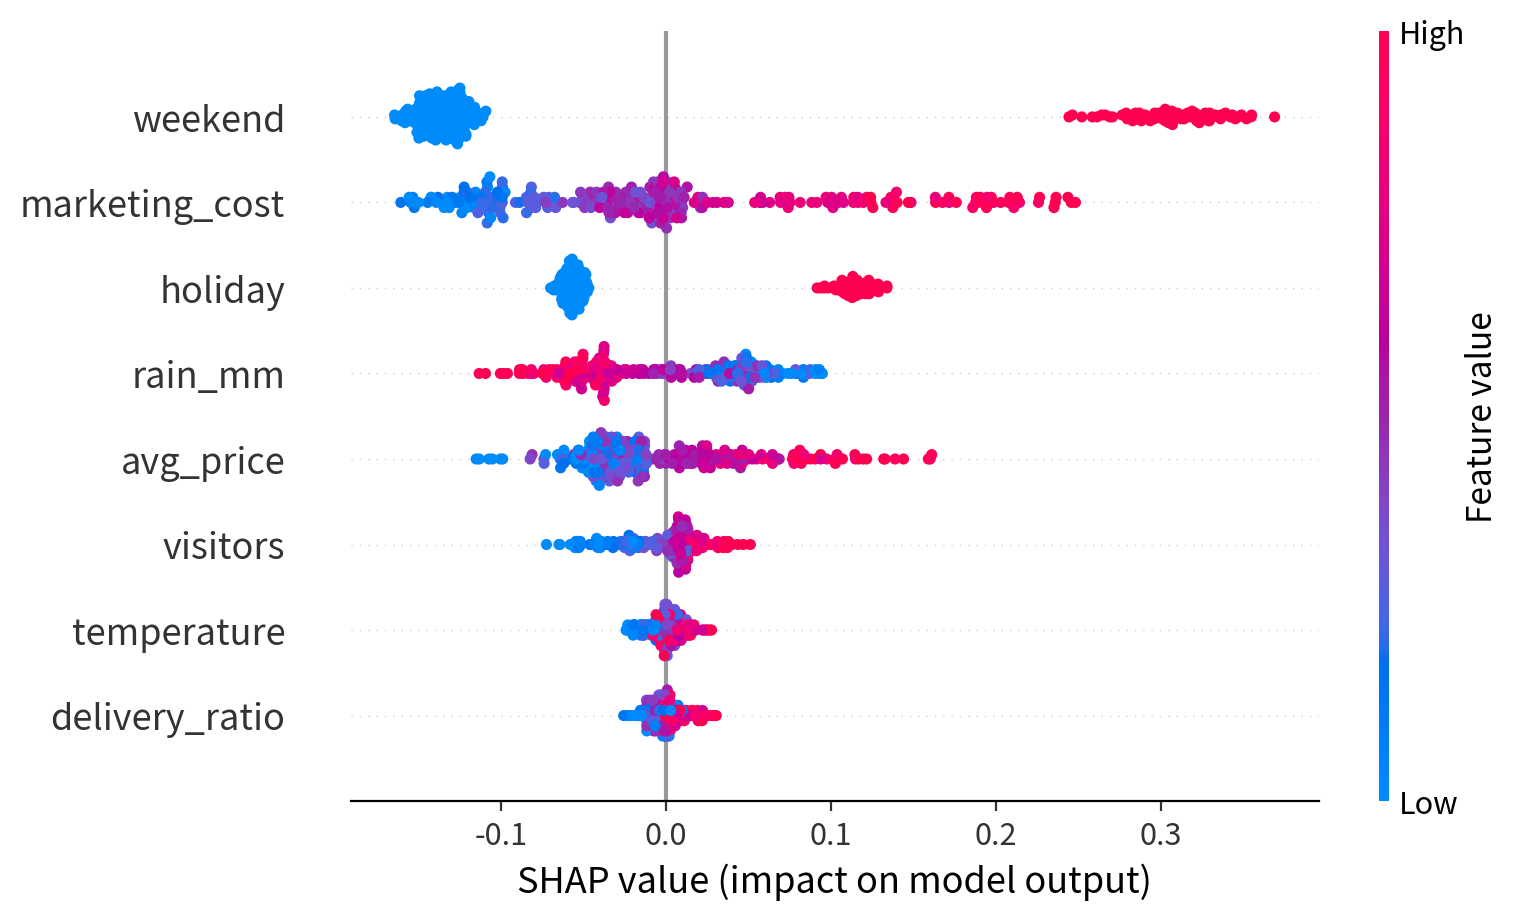

In [48]:
s.interpret_model(estimator=tuned,plot='summary',use_train_data=True)

### [8] 변수간 관계
- feature 매개변수를 통해 가장 영향력이 큰 변수와 다른 변수의 관계를 설정할 수 있다

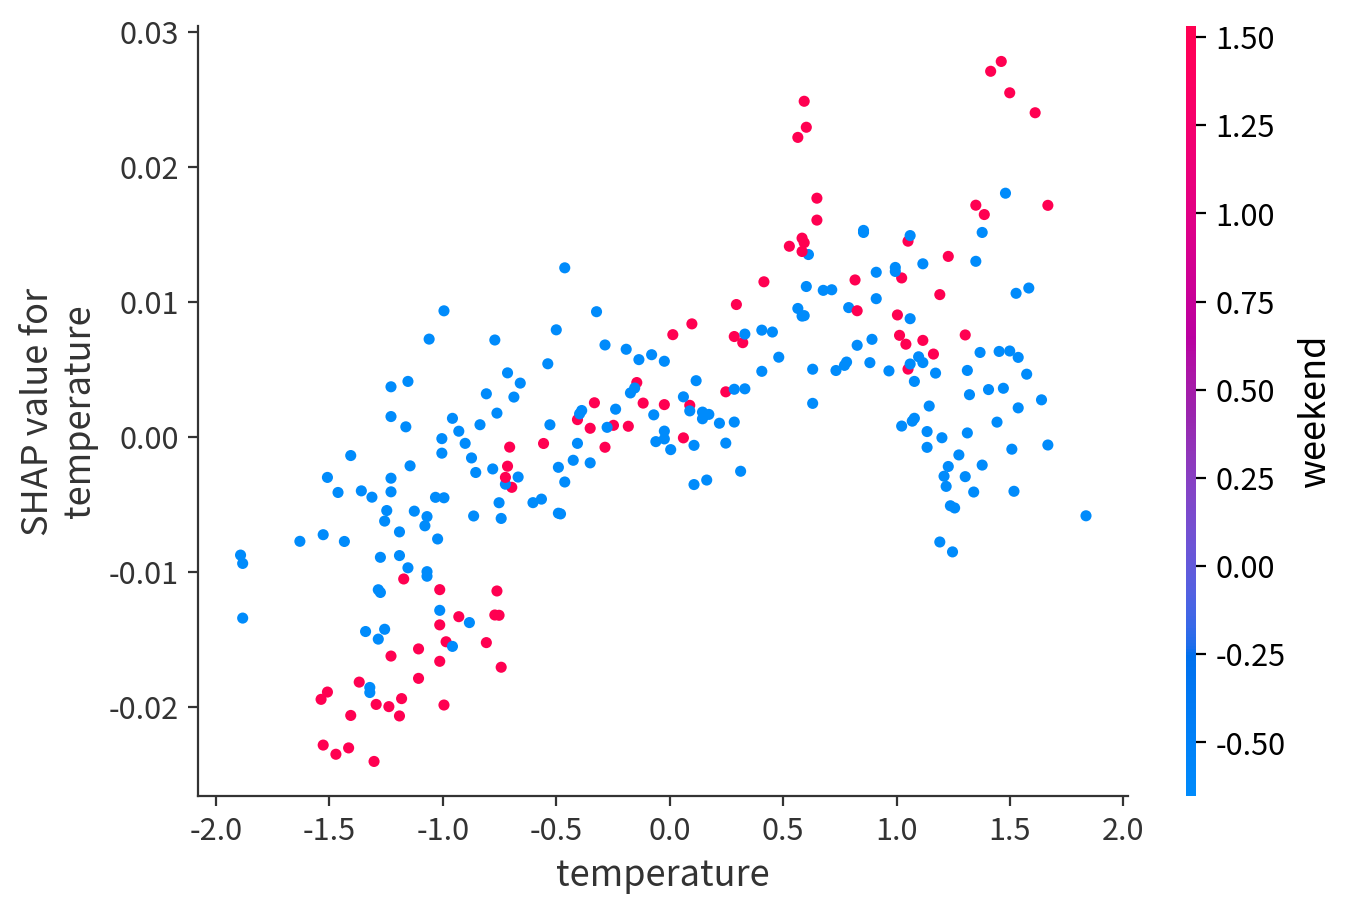

In [49]:
s.interpret_model(estimator=tuned,plot='correlation',use_train_data=True,feature='temperature')

## #04. 분석 결과 직접 확인하기
### [1] 훈련, 검증 데이터 추출
- 전처리가 완료된 데이터 반환
- get_config() 는 pycaret.regressor 객체의 메서드

In [50]:
# 원본 독립변수 (변환 전)
X = s.get_config("X")
y = s.get_config("y")

# 훈련 데이터 (데이터 변환 전)
X_train = s.get_config("X_train")
y_train = s.get_config("y_train")

# 테스트 데이터 (데이터 변환 전)
X_test = s.get_config("X_test")
y_test = s.get_config("y_test")

# 변환된 훈련 데이터
X_train_transformed = s.get_config("X_train_transformed")
y_train_transformed = s.get_config("y_train_transformed")

# 변환된 테스트 데이터
X_test_transformed = s.get_config("X_test_transformed")
y_test_transformed = s.get_config("y_test_transformed")

# 변환된 훈련 + 테스트 데이터셋
X_transformed = concat([X_train_transformed, X_test_transformed])
y_transformed = concat([y_train_transformed, y_test_transformed])

# 데이터 크기 확인
(
    X.shape, y.shape,
    (X_train.shape, y_train.shape),
    (X_test.shape, y_test.shape),
    (X_train_transformed.shape, y_train_transformed.shape),
    (X_test_transformed.shape, y_test_transformed.shape)
)


((353, 8),
 (353,),
 ((264, 8), (264,)),
 ((89, 8), (89,)),
 ((264, 8), (264,)),
 ((89, 8), (89,)))

#### 훈련 데이터의 독립변수 원본 확인

In [51]:
X_train

,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
date,,,,,,,,
2024-06-11,129,8590,8.987,0.410,2.028,14.200,0,0
2024-06-20,115,22020,8.412,0.380,2.219,8.000,0,0
2024-08-25,115,14630,9.457,0.490,2.251,-2.900,1,1
2024-11-22,137,16830,8.810,0.380,1.194,0.700,0,0
2024-12-30,106,13370,8.537,0.480,2.197,9.600,0,0
...,...,...,...,...,...,...,...,...
2024-03-30,123,13930,7.901,0.530,2.015,27.700,1,1
2024-06-04,114,25370,8.700,0.510,1.589,11.400,0,0
2024-01-14,101,11620,8.319,0.210,0.916,12.900,1,1


#### 훈련 데이터의 독립변수 전처리 결과 확인

In [52]:
X_train_transformed

,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
date,,,,,,,,
2024-06-11,0.916,-1.801,0.229,-0.296,0.594,0.406,-0.731,-0.653
2024-06-20,-0.415,1.761,-0.740,-0.549,0.884,-0.173,-0.731,-0.653
2024-08-25,-0.415,-0.199,1.020,0.378,0.933,-1.191,1.367,1.530
2024-11-22,1.677,0.385,-0.070,-0.549,-0.675,-0.855,-0.731,-0.653
2024-12-30,-1.271,-0.533,-0.529,0.294,0.851,-0.023,-0.731,-0.653
...,...,...,...,...,...,...,...,...
2024-03-30,0.345,-0.384,-1.600,0.715,0.573,1.667,1.367,1.530
2024-06-04,-0.510,2.650,-0.256,0.546,-0.074,0.145,-0.731,-0.653
2024-01-14,-1.747,-0.997,-0.897,-1.981,-1.097,0.285,1.367,1.530


### [2] 성능 평가
#### 파이프라인 확인
- 파이프라인에 머신러닝 모델 자체는 포함되어 있지 않다

In [53]:
pipeline=s.get_config('pipeline')
display(pipeline)

Pipeline(memory=FastMemory(location=C:\Users\itwill\AppData\Local\Temp\joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['visitors', 'avg_price',
                                             'marketing_cost', 'delivery_ratio',
                                             'rain_mm', 'temperature'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['weekend', 'holiday'],
                                    transformer=SimpleImputer(strat...
                 TransformerWrapper(include=['weekend', 'holiday'],
                                    transformer=OrdinalEncoder(cols=['weekend',
                                                                     'holiday'],
                                                               handle_missing='return_nan',
                                                               mapping=[{'col': 'weekend',
                                                                         'data_type': dtype('float64'),
                                                                         'mapping': 0.000    0
1.000    1
NaN     -1
dtype: int64},
                                                                        {'col': 'holiday',
                                                                         'data_type': dtype('float64'),
                                                                         'mapping': 0.000    0
1.000    1
NaN     -1
dtype: int64}]))),
                ('normalize',
                 TransformerWrapper(transformer=StandardScaler()))])

#### 시각화 초기화
- PyCaret 이 pyplot의 설정을 강제로 수정하기 떄문에 되돌리는 작업이 필요하다

In [54]:
init_pyplot()


✅ 시각화를 위한 한글 글꼴(NotoSansKR-Regular)이 자동 적용되었습니다.


#### 성능 평가 지표

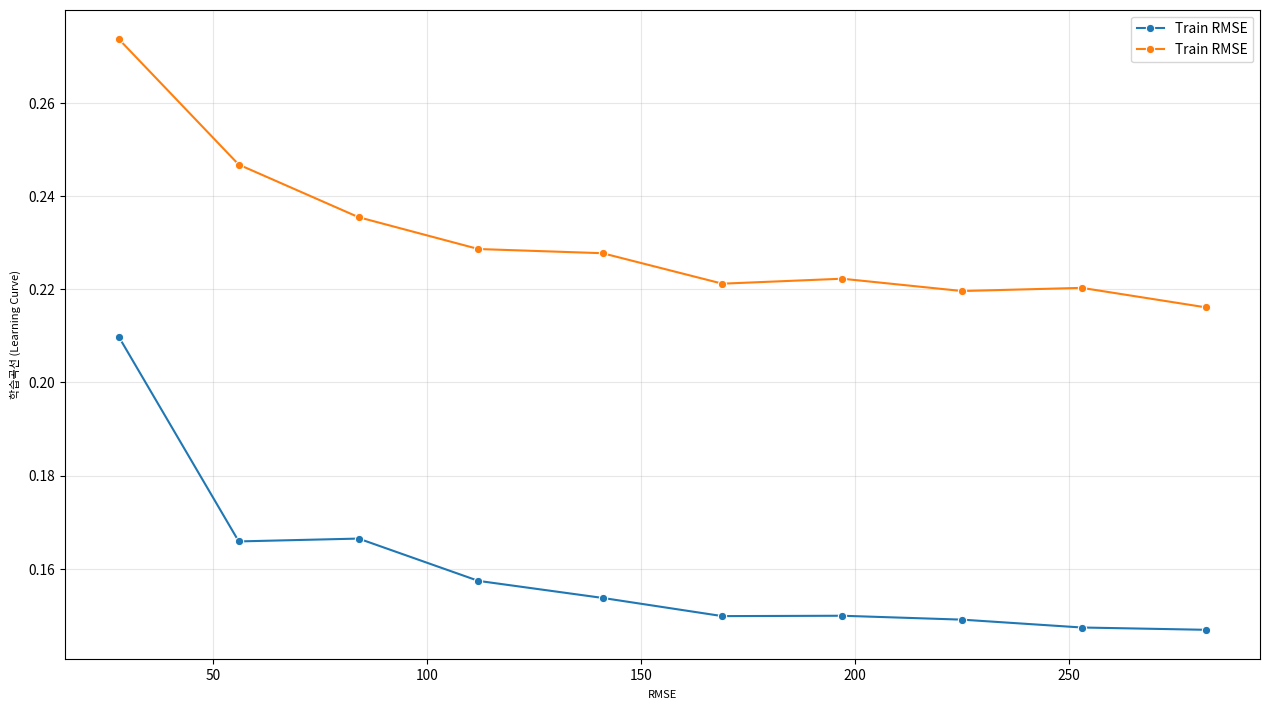

CPU times: total: 172 ms
Wall time: 3.47 s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
RandomForestRegressor,0.674,0.169,0.047,0.216,0.010,0.307,0.147,0.216,0.014,0.680,0.063,⚠️ 과대적합 (variance 큼)


In [55]:
%%time
hs_get_score_cv(
    tuned,
    X_test_transformed,
    y_test_transformed,
    X_transformed,
    y_transformed
)


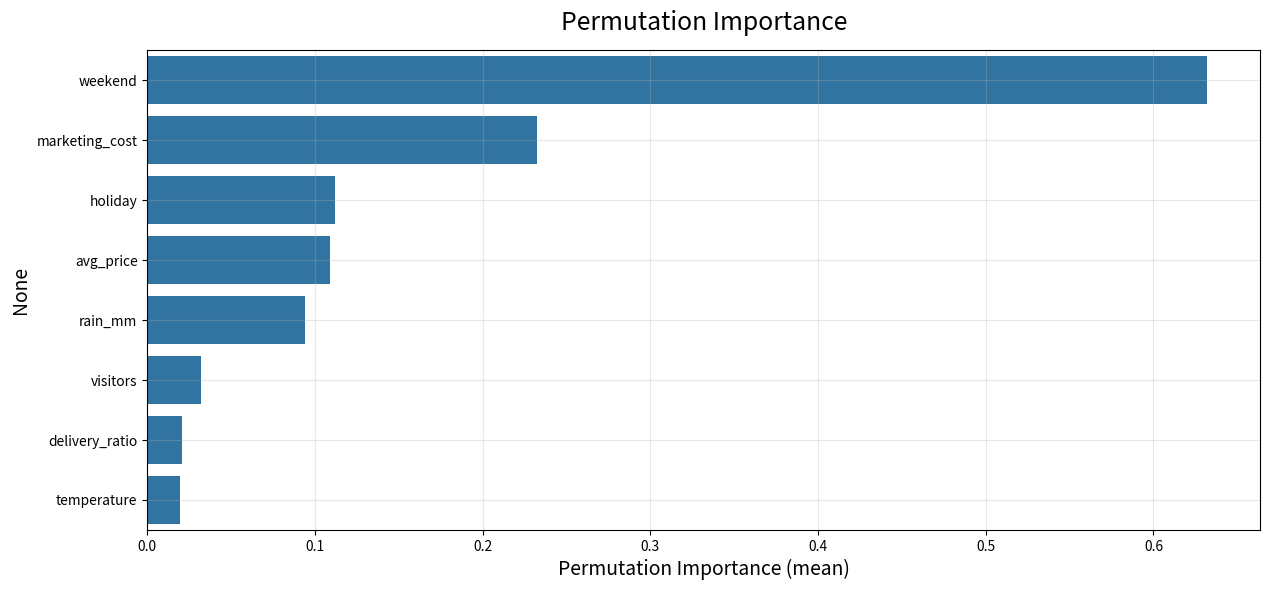

,importance_mean,importance_std
weekend,0.632,0.065
marketing_cost,0.232,0.027
holiday,0.112,0.015
avg_price,0.109,0.014
rain_mm,0.094,0.009
visitors,0.032,0.004
delivery_ratio,0.020,0.002
temperature,0.020,0.002


In [56]:
hs_feature_importance(tuned,X_train_transformed,y_train_transformed)

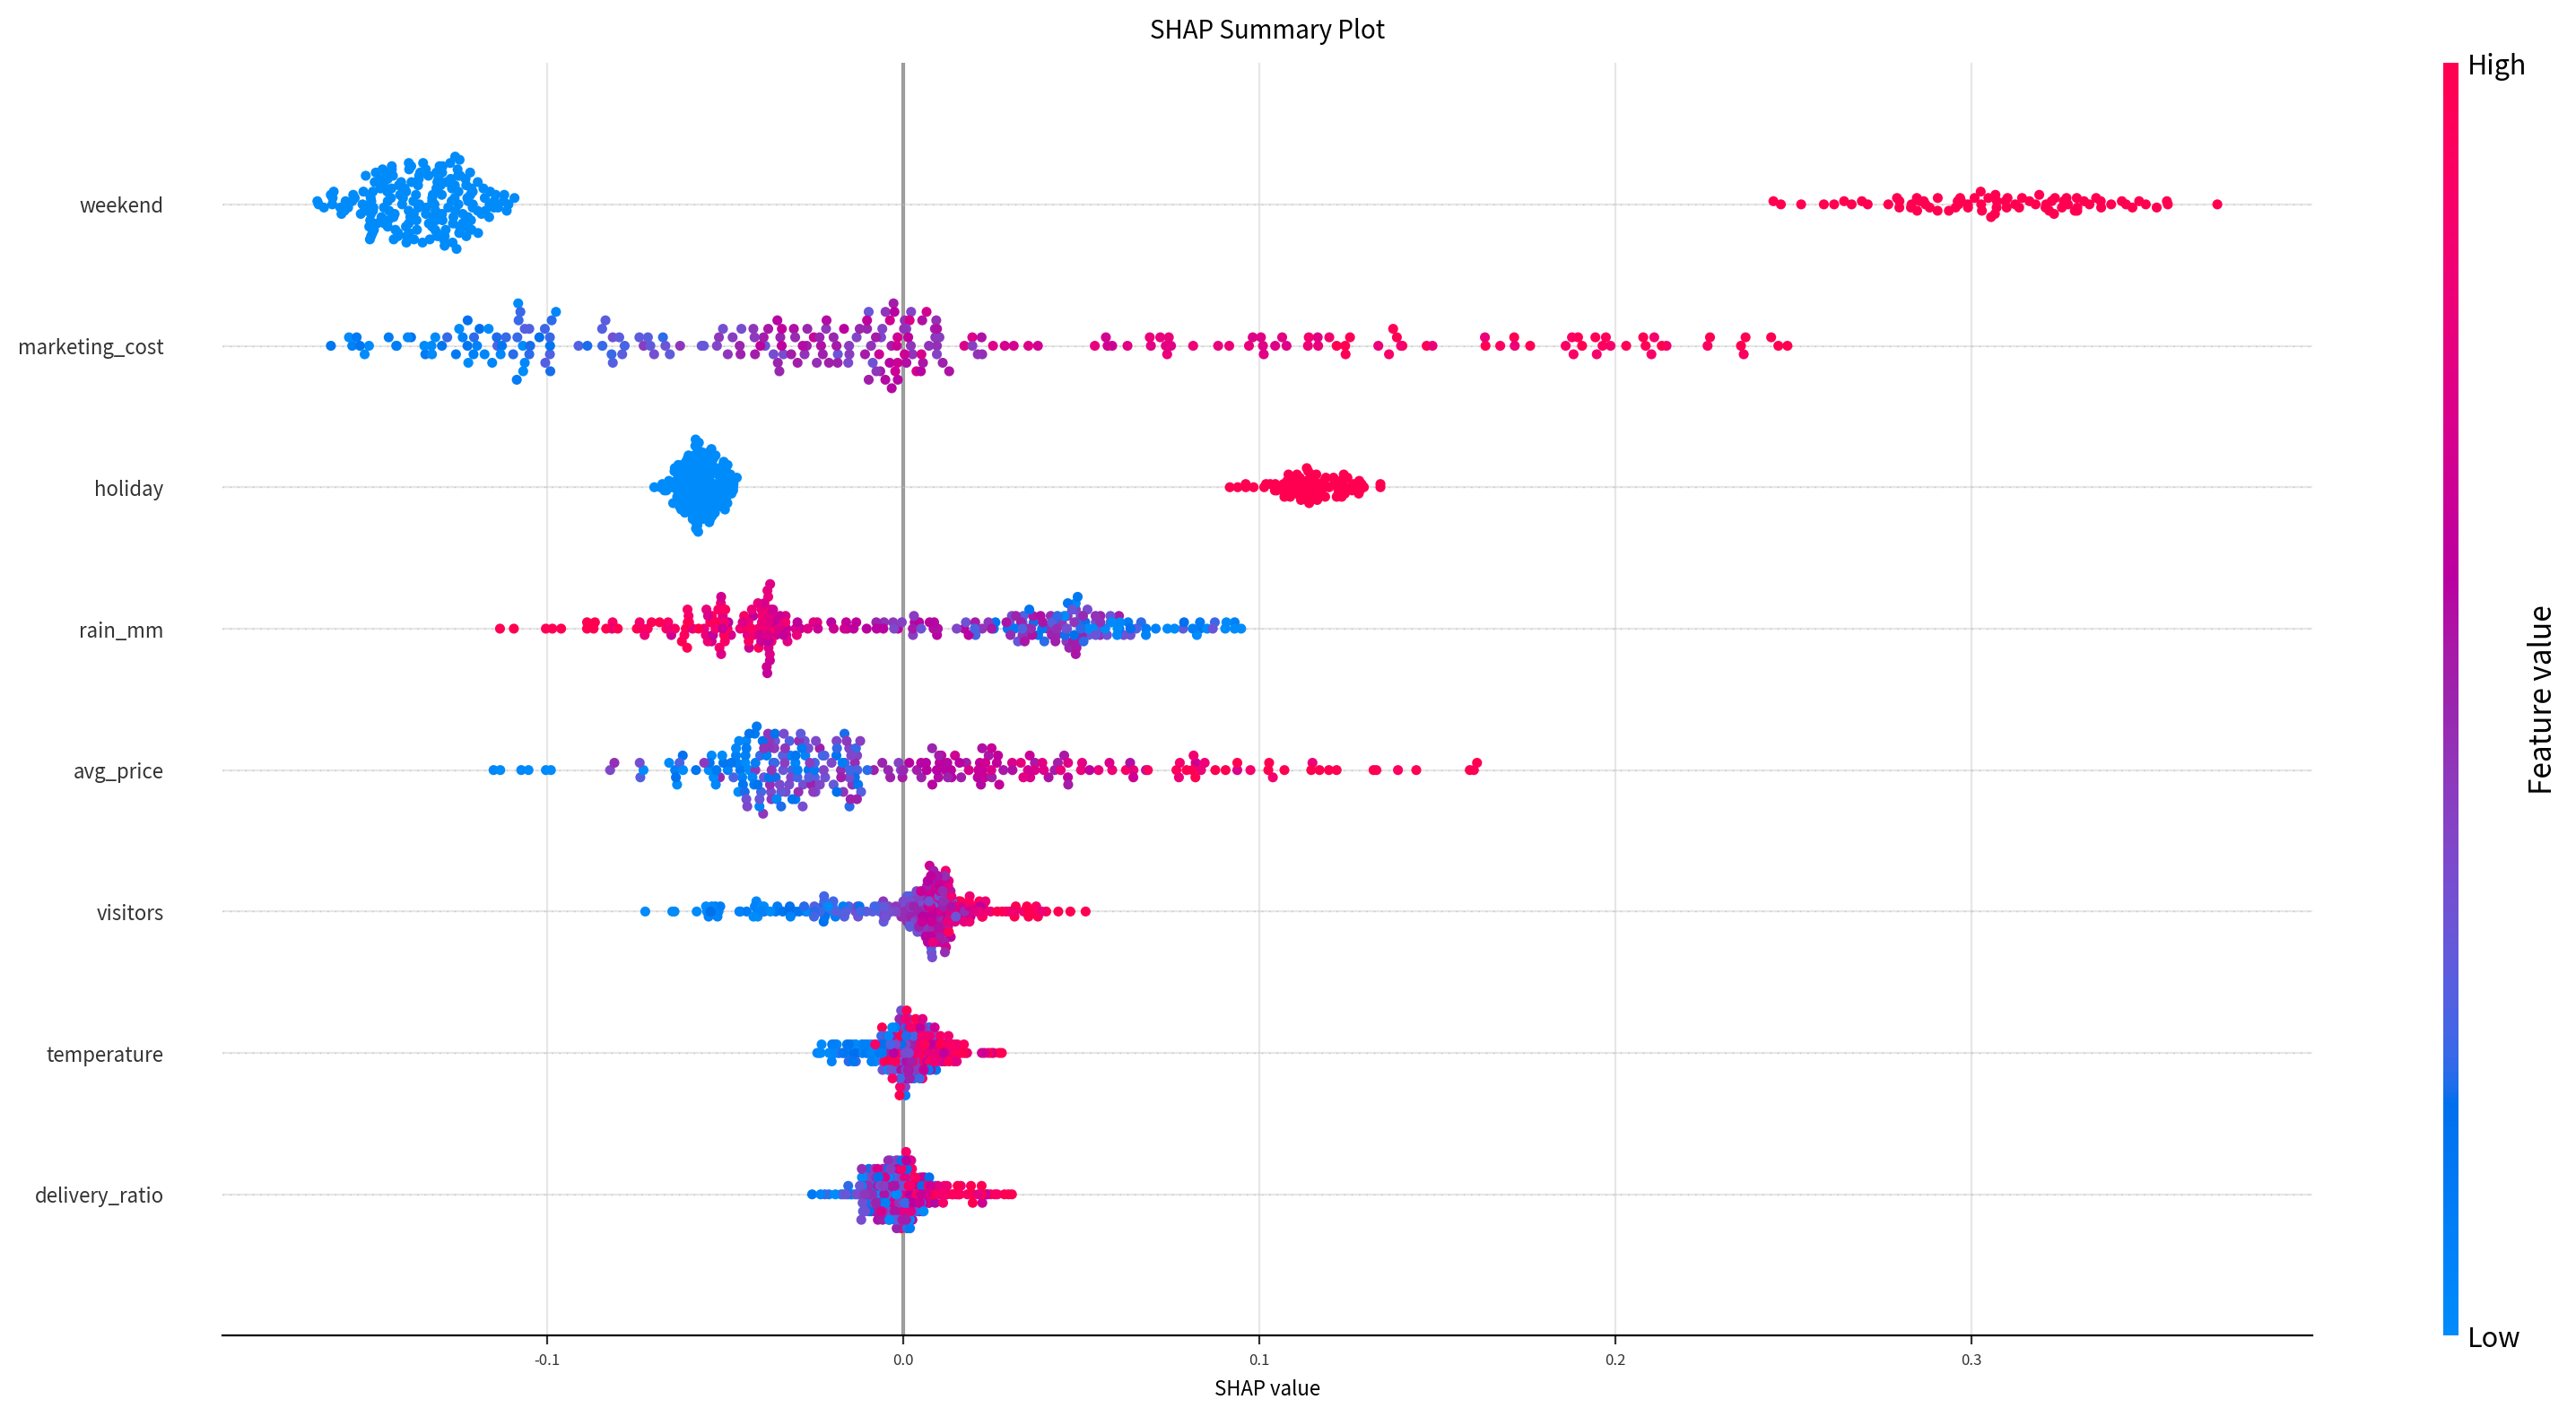

,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,variability,importance_ratio,importance_cumsum,is_important
0,weekend,0.187,-0.003,0.204,음(-) 경향,1.092,variable,0.401,0.401,core
1,marketing_cost,0.080,0.001,0.103,양(+) 경향,1.286,variable,0.173,0.574,core
2,holiday,0.077,0.003,0.082,양(+) 경향,1.067,variable,0.165,0.739,core
3,rain_mm,0.046,-0.001,0.051,음(-) 경향,1.108,variable,0.099,0.838,secondary
4,avg_price,0.043,-0.002,0.053,음(-) 경향,1.243,variable,0.092,0.930,secondary
5,visitors,0.018,0.000,0.023,양(+) 경향,1.301,variable,0.038,0.968,secondary
6,temperature,0.008,0.001,0.010,양(+) 경향,1.293,variable,0.017,0.985,secondary
7,delivery_ratio,0.007,-0.000,0.010,음(-) 경향,1.341,variable,0.015,1.000,secondary


In [58]:
import shap
df,v=hs_shap_analysis(tuned,X_train_transformed,width=1600)
df